In [33]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.patches as mpatches
import pandas as pd
import tensorflow as tf
import re

from xseas import SeasonDetect, X_labels


import matplotlib as mpl
from pathlib import Path

# Imposta stile globale
mpl.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

In [34]:
reference = xr.open_dataset('/Users/jacopograssi/Documents/XSeas/working_folder/clusterings/monsoon_all_vars_clust.nc')

In [35]:
import yaml

with open('paths.local.yaml', 'r') as file:
    paths = yaml.safe_load(file)

FIGURES_DIR = Path(paths['FIGURES_DIR'])
SUPP_FIGURES_DIR = Path(paths['SUPP_FIGURES_DIR'])
WORKING_FOLDER = Path(paths['WORKING_FOLDER'])

# Define key paths
SHAPEFILES_PATH = WORKING_FOLDER / 'shapefiles'
REFERENCES_PATH = WORKING_FOLDER / 'references'
CLUSTERING_PATH = WORKING_FOLDER / 'clusterings'
CONFIG_FILE = 'four_seas_all_vars.yaml'

WEIGHTS_DIR = os.path.join(WORKING_FOLDER, 'perceptron_model', 'four_seas_all_vars', 'weights')

In [36]:
feature_names = ["tas", "pr", "u850", "v850"]
season_names = ["winter", "premonsoon", "monsoon", "postmonsoon"]

data = {
    feature: np.full(
        (len(season_names), len(reference.lat), len(reference.lon)),
        np.nan,
        dtype=float,
    )
    for feature in feature_names
}

pattern = re.compile(r"model_(\d+)_(\d+)\.keras")

for fname in os.listdir(WEIGHTS_DIR):
    match = pattern.match(fname)
    if match is None:
        continue

    lat_idx = int(match.group(1))
    lon_idx = int(match.group(2))

    model_path = os.path.join(WEIGHTS_DIR, fname)
    model = tf.keras.models.load_model(model_path)

    weights, bias = model.layers[0].get_weights()

    # weights shape = (feature, season)
    abs_weights = np.abs(weights)

    # percent importance for each season
    # columns sum to 100
    importance = 100 * abs_weights / abs_weights.sum(axis=0, keepdims=True)

    for i, feature in enumerate(feature_names):
        data[feature][
            :,
            lat_idx,
            lon_idx,
        ] = importance[i, :]

importance_ds = xr.Dataset(
    {
        feature: (
            ("season", "lat", "lon"),
            data[feature],
        )
        for feature in feature_names
    },
    coords={
        "season": season_names,
        "lat": reference.lat,
        "lon": reference.lon,
    },
    attrs={
        "description": (
            "MLRC feature importance computed from absolute logistic-regression "
            "coefficients. For each grid point and season, feature importances "
            "sum to 100% across tas, pr, u850, and v850."
        )
    },
)

In [38]:
boundary = gpd.read_file(SHAPEFILES_PATH / 'boundary.gpkg')
s = SeasonDetect(WORKING_FOLDER, 'four_seas_all_vars.yaml')

✅ Using existing XSeas project at: /Users/jacopograssi/Documents/XSeas/working_folder
⚠️  Recommended key missing: parameters_projections


In [39]:
def clip(name, ds):
    bnd = gpd.read_file(SHAPEFILES_PATH / f'{name}.gpkg')

    ds = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    ds.rio.write_crs("epsg:4326", inplace=True);
    ds = ds.rio.clip(bnd.geometry.apply(mapping))
    return ds

In [54]:
names = ['HKK', 'him', 'central_india', 'southwest_india']
season_names = ['winter', 'pre-monsoon', 'monsoon', 'post-monsoon']

records = []

for idx_seas, season in enumerate(season_names):
    ds_season = importance_ds.isel(season=idx_seas)
    for region in names:
        ds_mask = clip(region, ds_season)
        records.append({
            'region': region,
            'season': season,
            'tas': float(ds_mask.tas.mean()),
            'pr': float(ds_mask.pr.mean()),
            'u850': float(ds_mask.u850.mean()),
            'v850': float(ds_mask.v850.mean()),
        })

df_importance = pd.DataFrame(records)

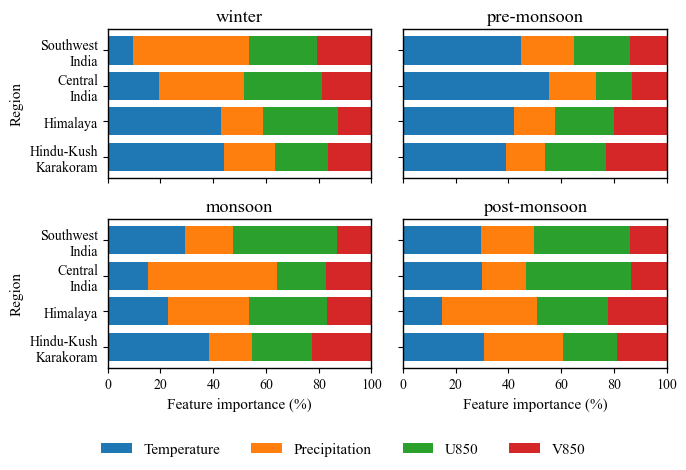

In [60]:
import matplotlib.pyplot as plt
import numpy as np

features = ["tas", "pr", "u850", "v850"]
feature_labels = {
    "tas": "Temperature",
    "pr": "Precipitation",
    "u850": "U850",
    "v850": "V850",
}

region_labels = {
    "HKK": "Hindu-Kush\nKarakoram",
    "him": "Himalaya",
    "central_india": "Central\nIndia",
    "southwest_india": "Southwest\nIndia",
}

season_names = ["winter", "pre-monsoon", "monsoon", "post-monsoon"]
region_names = ["HKK", "him", "central_india", "southwest_india"]

fig, axes = plt.subplots(
    2, 2,
    figsize=(7, 5),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for ax, season in zip(axes, season_names):

    df_season = (
        df_importance
        .loc[df_importance["season"] == season]
        .set_index("region")
        .loc[region_names]
    )

    left = np.zeros(len(region_names))

    for feature in features:
        values = df_season[feature].values

        ax.barh(
            [region_labels[r] for r in region_names],
            values,
            left=left,
            label=feature_labels[feature],
        )

        left += values

    ax.set_title(season)
    ax.set_xlim(0, 100)
    

axes[0].set_ylabel("Region")
axes[2].set_ylabel("Region")
axes[3].set_xlabel("Feature importance (%)")
axes[2].set_xlabel("Feature importance (%)")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
)

# fig.suptitle("MLRC feature importance by season and region", y=0.98)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

In [61]:
df_importance

,region,season,tas,pr,u850,v850
0,HKK,winter,44.164087,19.294096,20.009618,16.532199
1,him,winter,43.044994,15.746767,28.540784,12.667454
2,central_india,winter,19.409411,32.105479,29.862320,18.622789
3,southwest_india,winter,9.689980,43.903776,25.855336,20.550908
4,HKK,pre-monsoon,38.988545,14.915140,23.008458,23.087857
5,him,pre-monsoon,42.038965,15.766235,22.244298,19.950501
6,central_india,pre-monsoon,55.509623,17.642628,13.757164,13.090584
7,southwest_india,pre-monsoon,44.777403,20.107154,21.222813,13.892629
8,HKK,monsoon,38.227409,16.650820,22.708607,22.413164
9,him,monsoon,22.821543,30.625951,29.756999,16.795507
